# PJME hybrid load forecast: results

This notebook reads the artifacts produced by `pjme train` (run that first). All modelling code
lives in `src/pjme_forecast`. The notebook only inspects results, so nothing here can drift
from what production runs.

Hybrid model: `y(t) = base(t) + z(t)`. `base` is a Ridge model on calendar terms (weekly profile,
annual cycle × hour, holidays, trend). `z` is LightGBM trained on **lags of the residual z** plus `base(t)`.

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from pjme_forecast.config import load_config
from pjme_forecast.data import load_clean_series
from pjme_forecast.pipeline import load_bundle

cfg = load_config(ROOT / "config" / "default.yaml")
cfg["data"]["path"] = str(ROOT / cfg["data"]["path"])
series = load_clean_series(cfg)
report = json.loads((ROOT / "artifacts/reports/metrics.json").read_text())
print("data:", series.index[0], "->", series.index[-1], f"({len(series):,} hours)")
print("split:", report["split"])

data: 2002-01-01 01:00:00 -> 2018-08-03 00:00:00 (145,392 hours)
split: {'train': ['2002-01-01 01:00:00', '2014-12-31 23:00:00'], 'val': ['2015-01-01 00:00:00', '2016-12-31 23:00:00'], 'test': ['2017-01-01 00:00:00', '2018-08-03 00:00:00']}


## Held-out test metrics (2017-01-01 → 2018-08-03)
`1h_*` = one hour ahead. `day_ahead_*` = recursive 24 h forecast issued every midnight.

In [2]:
m = pd.DataFrame(report["metrics"]).T
cols = ["1h_MAE", "1h_MAPE", "day_ahead_MAE", "day_ahead_RMSE", "day_ahead_MAPE", "day_ahead_R2", "day_ahead_bias"]
m[cols].astype(float).round(2)

,1h_MAE,1h_MAPE,day_ahead_MAE,day_ahead_RMSE,day_ahead_MAPE,day_ahead_R2,day_ahead_bias
naive_24h,2300.08,7.32,2300.12,3134.26,7.32,0.74,-15.03
naive_168h,3511.18,10.99,3511.41,4794.15,10.99,0.39,-67.06
linear,385.89,1.24,2032.60,2758.22,6.48,0.80,354.95
lightgbm,209.57,0.66,1382.48,2064.49,4.23,0.89,173.35
hybrid,195.39,0.61,1328.94,2018.33,4.08,0.89,257.50
ensemble,187.37,0.59,1311.42,1974.75,4.01,0.90,215.43


In [3]:
by_h = pd.DataFrame(report["mae_by_horizon"], index=range(1, report["horizon"] + 1))
by_h.index.name = "hours ahead"
(1 - by_h["hybrid"] / by_h["lightgbm"]).mul(100).round(1).rename("hybrid improvement vs LightGBM, %").to_frame().T

hours ahead,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
"hybrid improvement vs LightGBM, %",-1.3,4.8,10.0,10.0,10.0,9.5,12.3,14.8,12.7,8.3,...,1.6,2.5,3.1,3.4,3.4,2.9,2.4,2.0,1.7,1.8


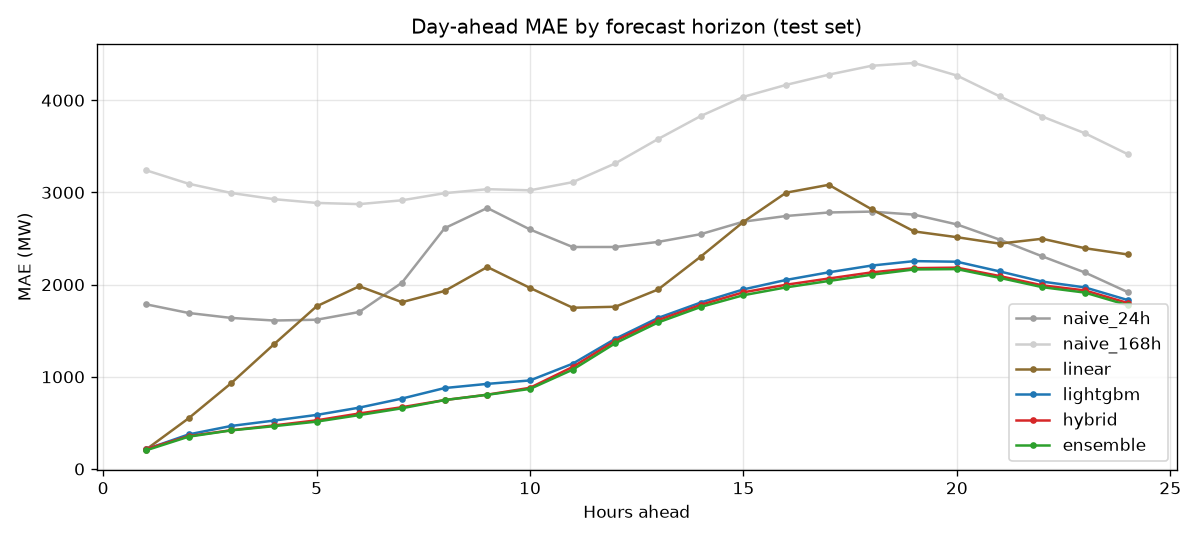

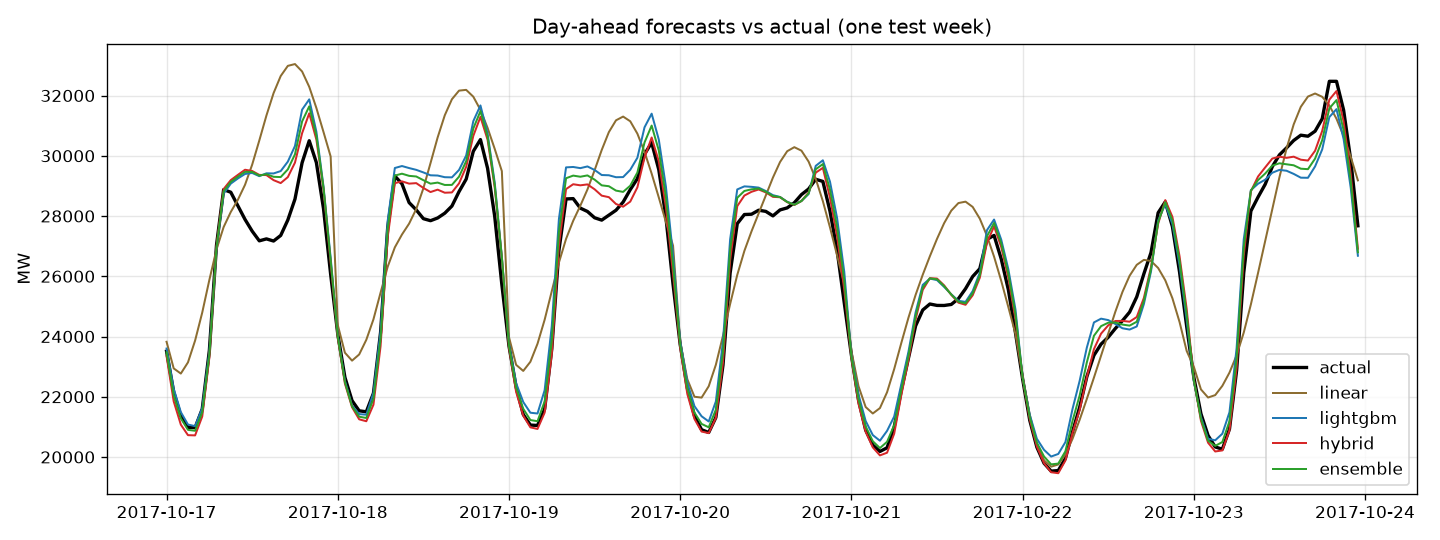

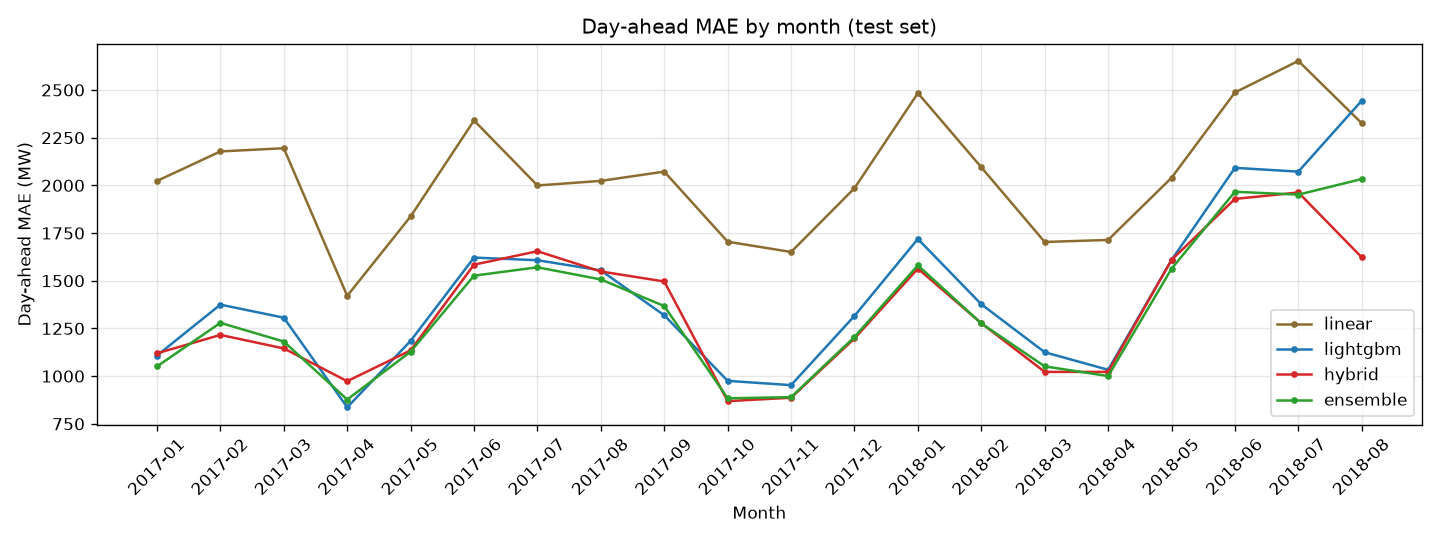

In [4]:
for name in ["mae_by_horizon.png", "test_week.png", "mae_by_month.png"]:
    display(Image(filename=str(ROOT / "artifacts/reports" / name)))

## Why the fixed hybrid is robust

The original notebook's residual model used lags of raw load. With that design, an error of +c
in the trend/base component moves the final forecast by +c. Here the lags are computed on the
residual, so the same error shifts the residual lags by −c and cancels out. The cell below
injects a +1,000 MW error into the base of the trained production model and measures how much
the one-hour-ahead forecast moves.

In [5]:
model, meta = load_bundle(ROOT / "artifacts/model.joblib")
before = model.predict_one_step(series, "2018-01-01")
original = model.base.predict
model.base.predict = lambda idx: original(idx) + 1000.0
after = model.predict_one_step(series, "2018-01-01")
model.base.predict = original
print(f"base shifted by +1000 MW -> forecast moved by {float((after - before).mean()):+.1f} MW on average")

base shifted by +1000 MW -> forecast moved by +15.9 MW on average


## Production forecast: next 24 hours after the end of the data

,forecast,base,residual
timestamp,,,
2018-08-03 01:00:00,32913.0,32076.0,837.0
2018-08-03 02:00:00,31209.0,30098.0,1111.0
2018-08-03 03:00:00,30119.0,28800.0,1319.0
2018-08-03 04:00:00,29494.0,28046.0,1448.0
2018-08-03 05:00:00,29626.0,28045.0,1581.0
2018-08-03 06:00:00,30922.0,29260.0,1662.0
2018-08-03 07:00:00,32997.0,31333.0,1664.0
2018-08-03 08:00:00,35388.0,33875.0,1513.0
2018-08-03 09:00:00,37655.0,36316.0,1339.0


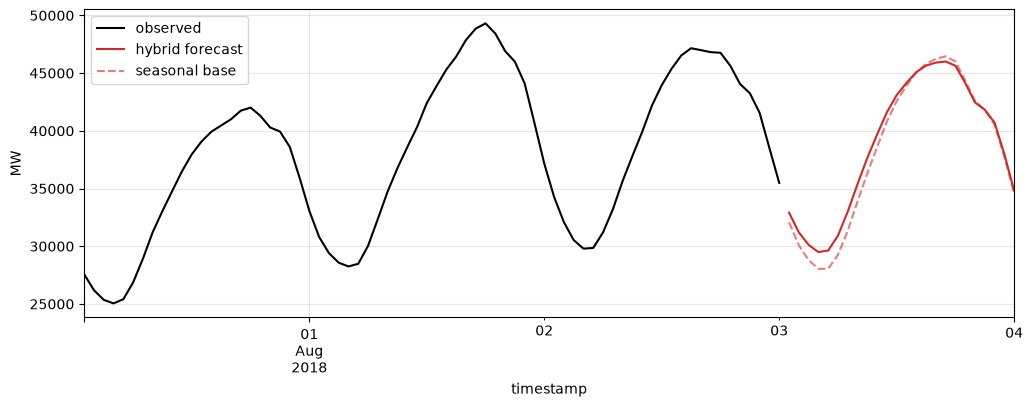

In [6]:
fc = model.forecast(series, horizon=24)
ax = series.iloc[-72:].plot(figsize=(12, 4), color="black", label="observed")
fc["forecast"].plot(ax=ax, color="#d62728", label="hybrid forecast")
fc["base"].plot(ax=ax, color="#d62728", ls="--", alpha=0.6, label="seasonal base")
ax.set_ylabel("MW"); ax.legend(); ax.grid(alpha=0.3)
fc.round(0).head(24)

In [7]:
print(json.dumps({k: meta[k] for k in ["model_kind", "trained_on", "created_at", "package_version"]}, indent=2))

{
  "model_kind": "hybrid",
  "trained_on": [
    "2002-01-01 01:00:00",
    "2018-08-03 00:00:00"
  ],
  "created_at": "2026-09-23T19:18:43+00:00",
  "package_version": "1.0.0"
}
